In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [44]:
df = pd.read_csv("height-weight.csv")

In [45]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [46]:
##scatter plot
plt.scatter(df["Weight"], df["Height"])
plt.xlabel("Weight")
plt.ylabel("Height")

Text(38.097222222222214, 0.5, 'Height')

In [47]:
## Correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


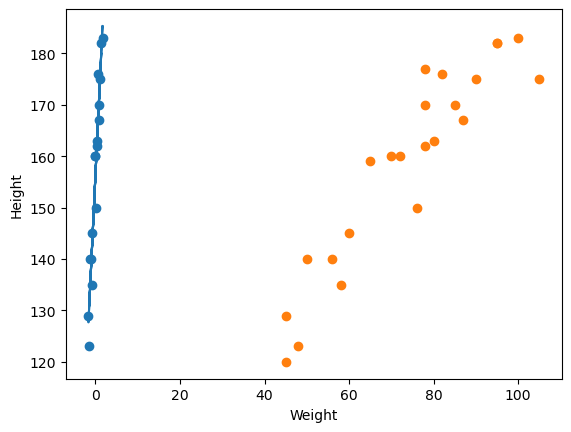

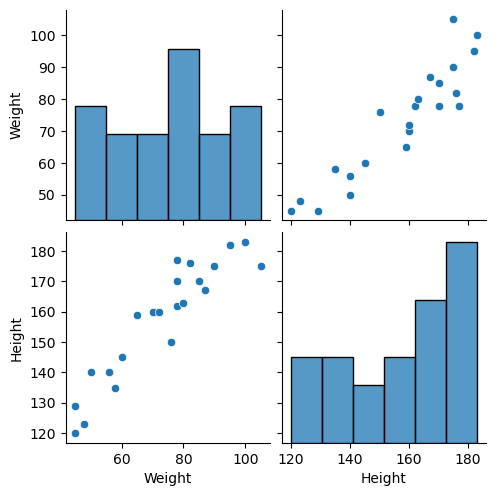

In [48]:
## Seaborn for visualization
import seaborn as sns

sns.pairplot(df)
plt.show()

In [49]:
## Independent and dependent features
X = df[["Weight"]]  ### independent features should be data frame or 2 dimesnionalarray
y = df["Height"]  ## this variiable can be in series or 1d array

In [50]:
X_series = df["Weight"]
np.array(X_series).shape

(23,)

In [51]:
np.array(y).shape

(23,)

In [52]:
## Train Test Split
from sklearn.model_selection import train_test_split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [54]:
## Standardization
from sklearn.preprocessing import StandardScaler

In [55]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [ ]:
X_test = scaler.transform(X_test)

In [57]:
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [58]:
## Apply Simple Linear Regression
from sklearn.linear_model import LinearRegression

In [59]:
regression = LinearRegression(n_jobs=-1)

In [60]:
regression.fit(X_train, y_train)

LinearRegression(n_jobs=-1)

In [61]:
print("Coefficient or slope:", regression.coef_)
print("Intercept:", regression.intercept_)

Coefficient or slope: [17.2982057]
Intercept: 156.47058823529412


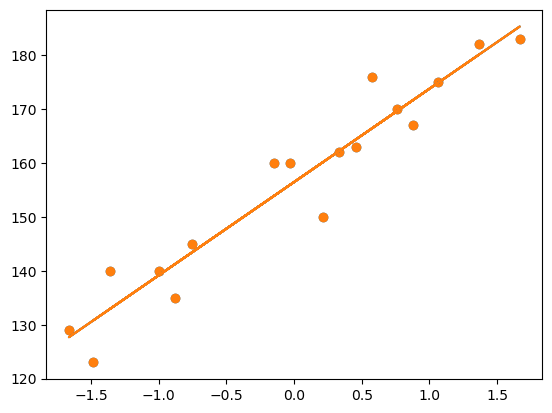

In [74]:
## plot Training data plot best fit line
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train))

plt.show()

### prediction of test data

1. predicted height output= intercept +coef\_(Weights)
2. y_pred_test =156.470 + 17.29(X_test)


In [75]:
## Prediction for test data
y_pred = regression.predict(X_test)

In [76]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [77]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.665125886795005
10.716374991212605


## R square

Formula

$$R^2 = 1 - \frac{SSR}{SST}$$

R^2 = coefficient of determination
SSR = sum of squares of residuals
SST = total sum of squares


In [78]:
from sklearn.metrics import r2_score

In [79]:
score = r2_score(y_test, y_pred)
print(score)

0.7360826717981276


**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables


In [80]:
# display adjusted R-squared
1 - (1 - score) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

0.6701033397476595

In [81]:
## OLS Linear Regression
import statsmodels.api as sm

In [82]:
model = sm.OLS(y_train, X_train).fit()

In [83]:
prediction = model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [84]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Thu, 12 Mar 2026   Prob (F-statistic):                       0.664
Time:                        23:00:33   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=17
  res = hypotest_fun_out(*samples, **kwds)


In [86]:
## Prediction For new data
regression.predict(scaler.transform([[72]]))

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])